# Chuyên đề 2 – BT 2: So sánh Insert Sort và Heap Sort (C++)

- Cài đặt 2 thuật toán sắp xếp cho mảng N phần tử.
- Đo thời gian chạy thực tế khi N tăng.
- C++17 chạy trực tiếp trên Google Colab bằng `g++`.
- Bản này dùng **Heap Sort chuẩn O(N log N)** và benchmark theo các mốc N để chạy nhanh hơn.


In [1]:
%%writefile main.cpp
#include <iostream>
#include <vector>
#include <random>
#include <chrono>
#include <fstream>
#include <algorithm>
#include <iomanip>
using namespace std;
using Clock = chrono::high_resolution_clock;

// a. Insert Sort - O(N^2)
void insertionSort(vector<int>& a) {
    for (int i = 1; i < (int)a.size(); ++i) {
        int key = a[i];
        int j = i - 1;
        while (j >= 0 && a[j] > key) {
            a[j + 1] = a[j];
            --j;
        }
        a[j + 1] = key;
    }
}

// Hàm vun đống max-heap - O(log N)
void heapify(vector<int>& a, int n, int i) {
    while (true) {
        int largest = i;
        int left = 2 * i + 1;
        int right = 2 * i + 2;

        if (left < n && a[left] > a[largest]) largest = left;
        if (right < n && a[right] > a[largest]) largest = right;

        if (largest == i) break;
        swap(a[i], a[largest]);
        i = largest;
    }
}

// b. Heap Sort - O(N log N)
void heapSort(vector<int>& a) {
    int n = (int)a.size();

    // Build max heap - O(N)
    for (int i = n / 2 - 1; i >= 0; --i)
        heapify(a, n, i);

    // Đưa phần tử lớn nhất về cuối
    for (int i = n - 1; i > 0; --i) {
        swap(a[0], a[i]);
        heapify(a, i, 0);
    }
}

bool sortedAscending(const vector<int>& a) {
    return is_sorted(a.begin(), a.end());
}

double measureInsertion(const vector<int>& input) {
    vector<int> a = input;
    auto t1 = Clock::now();
    insertionSort(a);
    auto t2 = Clock::now();
    return chrono::duration<double>(t2 - t1).count();
}

double measureHeap(const vector<int>& input) {
    vector<int> a = input;
    auto t1 = Clock::now();
    heapSort(a);
    auto t2 = Clock::now();
    return chrono::duration<double>(t2 - t1).count();
}

int main() {
    // Các mốc này đủ để thấy rõ xu hướng nhưng chạy nhanh trên Colab.
    const vector<int> sizes = {100, 500, 1000, 2000, 5000, 10000, 20000, 50000, 100000};

    mt19937 rng(123456); // cố định seed để kết quả có thể lặp lại
    uniform_int_distribution<int> dist(0, 1000000);

    ofstream csv("running_time.csv");
    csv << "N,insert_sort,heap_sort\n";

    cout << fixed << setprecision(6);
    cout << "Benchmark C++\n";
    cout << "N\tInsert Sort (s)\tHeap Sort (s)\n";

    for (int n : sizes) {
        vector<int> data(n);
        for (int& x : data) x = dist(rng);

        double tInsert = measureInsertion(data);
        double tHeap = measureHeap(data);

        csv << n << ',' << tInsert << ',' << tHeap << '\n';
        cout << n << '\t' << tInsert << '\t\t' << tHeap << '\n';
    }
    csv.close();

    // Test với mảng mẫu
    vector<int> test = {9, 4, 3, 8, 10, 2, 5, 5, 5};
    vector<int> a = test, b = test;
    insertionSort(a);
    heapSort(b);

    cout << "\nTest Insert Sort: ";
    for (int x : a) cout << x << ' ';
    cout << "\nTest Heap Sort:   ";
    for (int x : b) cout << x << ' ';
    cout << "\n\nInsert Sort: " << (sortedAscending(a) ? "DUNG" : "SAI");
    cout << "\nHeap Sort:   " << (sortedAscending(b) ? "DUNG" : "SAI") << '\n';
    cout << "\nDa tao file running_time.csv\n";
    return 0;
}


Writing main.cpp


In [2]:
!g++ -O2 -std=c++17 main.cpp -o main
!./main

main.cpp:97:41: warning: multi-character character constant []8;;https://gcc.gnu.org/onlinedocs/gcc/Warning-Options.html#index-Wmultichar-Wmultichar]8;;]
   97 |         cout << n << '\t' << tInsert << '\t\t' << tHeap << '\n';
      |                                         ^~~~~~
Benchmark C++
N	Insert Sort (s)	Heap Sort (s)
100	0.00000523130.000007
500	0.00010623130.000043
1000	0.00032723130.000065
2000	0.00092823130.000110
5000	0.00376523130.000309
10000	0.01452323130.000685
20000	0.06270423130.001503
50000	0.37068123130.004221
100000	1.46809423130.009425

Test Insert Sort: 2 3 4 5 5 5 8 9 10 
Test Heap Sort:   2 3 4 5 5 5 8 9 10 

Insert Sort: DUNG
Heap Sort:   DUNG

Da tao file running_time.csv


## Vẽ đồ thị running time

Kết quả đo từ chương trình C++ được lưu trong `running_time.csv`.

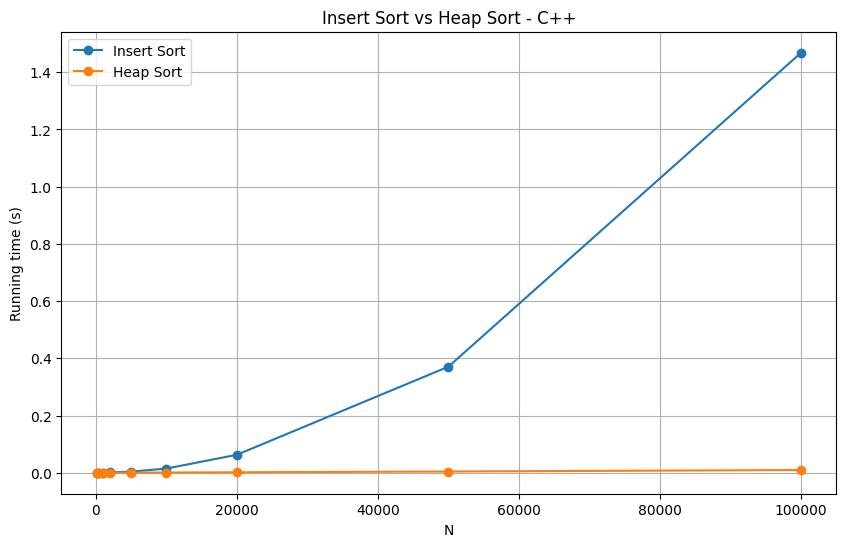

,N,insert_sort,heap_sort
0,100,0.000005,0.000007
1,500,0.000106,0.000043
2,1000,0.000327,0.000065
3,2000,0.000928,0.000110
4,5000,0.003765,0.000309
5,10000,0.014523,0.000685
6,20000,0.062704,0.001503
7,50000,0.370681,0.004221
8,100000,1.468090,0.009425


In [3]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("running_time.csv")

plt.figure(figsize=(10, 6))
plt.plot(df["N"], df["insert_sort"], marker="o", label="Insert Sort")
plt.plot(df["N"], df["heap_sort"], marker="o", label="Heap Sort")
plt.xlabel("N")
plt.ylabel("Running time (s)")
plt.title("Insert Sort vs Heap Sort - C++")
plt.legend()
plt.grid(True)
plt.show()

display(df)

Qua đồ thị thời gian chạy thực tế, có thể thấy khi kích thước mảng N tăng, thời gian thực thi của cả hai thuật toán đều tăng. Tuy nhiên, thời gian chạy của Insert Sort tăng nhanh hơn đáng kể so với Heap Sort. Khi N còn nhỏ, sự chênh lệch giữa hai thuật toán không lớn, nhưng khi N tăng thì Heap Sort cho thời gian thực thi thấp hơn rõ rệt.

Kết quả này phù hợp với độ phức tạp của hai thuật toán: Insert Sort có độ phức tạp trung bình và xấu nhất là O(N²), trong khi Heap Sort có độ phức tạp O(N log N). Vì vậy, Heap Sort phù hợp hơn khi cần sắp xếp các mảng có kích thước lớn.